## Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from scipy import stats
from pathlib import Path

# ── Capstone colour palette ──────────────────────────────────────────────────
PAL = {
    'navy':    '#1B4F72',
    'blue':    '#2E86C1',
    'sky':     '#AED6F1',
    'ice':     '#D6EAF8',
    'amber':   '#E67E22',
    'brick':   '#C0392B',
    'fern':    '#27AE60',
    'charcoal':'#2C3E50',
    'slate':   '#7F8C8D',
    'silver':  '#BDC3C7',
    'cloud':   '#F2F3F4',
}

mpl.rcParams.update({
    'figure.facecolor':   PAL['cloud'],
    'axes.facecolor':     'white',
    'axes.edgecolor':     PAL['silver'],
    'axes.labelcolor':    PAL['charcoal'],
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.titlecolor':    PAL['navy'],
    'axes.labelsize':     10,
    'xtick.color':        PAL['slate'],
    'ytick.color':        PAL['slate'],
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'grid.color':         PAL['silver'],
    'grid.alpha':         0.4,
    'grid.linewidth':     0.5,
    'axes.grid':          False,
    'legend.fontsize':    9,
    'legend.framealpha':  0.9,
    'legend.edgecolor':   PAL['silver'],
    'font.family':        'sans-serif',
    'font.size':          10,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
})

def clean_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color(PAL['silver'])
    ax.spines['left'].set_color(PAL['silver'])

# Paths — relative from notebooks/ folder
DATA = Path(r'..\data')
ICI_PATH = DATA / 'ici' / 'ret_25_q3_data.xls'
SP500_PATH = DATA / 'module5_priceimpact' / 'factset_sp500_price_history.xlsx'
CENSUS_PATH = DATA / 'processed' / 'census_65plus_population.csv'

print('Paths configured.')
print(f'  ICI:    {ICI_PATH} — exists: {ICI_PATH.exists()}')
print(f'  S&P:    {SP500_PATH} — exists: {SP500_PATH.exists()}')
print(f'  Census: {CENSUS_PATH} — exists: {CENSUS_PATH.exists()}')

Paths configured.
  ICI:    ..\data\ici\ret_25_q3_data.xls — exists: True
  S&P:    ..\data\module5_priceimpact\factset_sp500_price_history.xlsx — exists: True
  Census: ..\data\processed\census_65plus_population.csv — exists: True


## Load and Parse Data Sources
ICI Table 20 (quarterly equity MF flows), S&P 500 returns, and Census 65+ population.

In [3]:
# Load and parse ICI Table 20 — quarterly equity net flows
raw_t20 = pd.read_excel(ICI_PATH, sheet_name='Table 20', header=None)

rows = raw_t20.iloc[42:117].copy()
rows.columns = ['quarter', 'lt_total', 'equity', 'hybrid', 'bond', 'money_market', 'total_ret']

rows = rows[['quarter', 'equity']].copy()
rows['quarter'] = rows['quarter'].astype(str).str.strip()
rows['equity'] = pd.to_numeric(rows['equity'], errors='coerce').fillna(0)

def parse_quarter(q):
    year, qtr = q.split(':')
    month = {'Q1': 1, 'Q2': 4, 'Q3': 7, 'Q4': 10}[qtr]
    return pd.Timestamp(int(year), month, 1)

rows['date'] = rows['quarter'].apply(parse_quarter)
rows = rows.set_index('date').sort_index()

print(f'Quarterly equity net flows: {len(rows)} observations')
print(f"Date range: {rows.index[0].strftime('%Y-%m')} to {rows.index[-1].strftime('%Y-%m')}")
print(f'\nFirst 5:')
print(rows[['quarter', 'equity']].head())
print(f'\nLast 5:')
print(rows[['quarter', 'equity']].tail())
print(f'\nBasic stats ($ billions):')
print(rows['equity'].describe().round(1))

Quarterly equity net flows: 75 observations
Date range: 2007-01 to 2025-07

First 5:
            quarter  equity
date                       
2007-01-01  2007:Q1      23
2007-04-01  2007:Q2       6
2007-07-01  2007:Q3      -1
2007-10-01  2007:Q4      -3
2008-01-01  2008:Q1     -31

Last 5:
            quarter  equity
date                       
2024-07-01  2024:Q3     -72
2024-10-01  2024:Q4    -138
2025-01-01  2025:Q1    -131
2025-04-01  2025:Q2    -110
2025-07-01  2025:Q3    -367

Basic stats ($ billions):
count     75.0
mean     -35.2
std       54.0
min     -367.0
25%      -54.0
50%      -30.0
75%       -4.5
max       33.0
Name: equity, dtype: float64


In [4]:
sp = pd.read_excel(SP500_PATH, header=None, skiprows=2)
sp = sp.iloc[:, [0, 1]].copy()
sp.columns = ['Date', 'Price']
sp['Date'] = pd.to_datetime(sp['Date'], errors='coerce')
sp['Price'] = pd.to_numeric(sp['Price'], errors='coerce')
sp = sp.dropna().sort_values('Date').reset_index(drop=True)

print(f'Weekly prices: {len(sp)} observations')
print(f"Date range: {sp['Date'].min().strftime('%Y-%m-%d')} to {sp['Date'].max().strftime('%Y-%m-%d')}")

sp['qtr'] = sp['Date'].dt.to_period('Q')
qtr_prices = sp.groupby('qtr')['Price'].last().sort_index()
qtr_returns = qtr_prices.pct_change() * 100
qtr_returns = qtr_returns.dropna()
qtr_returns.index = qtr_returns.index.to_timestamp()
qtr_returns.name = 'sp500_return'

print(f'\nQuarterly returns: {len(qtr_returns)} observations')
print(f"Date range: {qtr_returns.index[0].strftime('%Y-%m')} to {qtr_returns.index[-1].strftime('%Y-%m')}")
print(f'\nBasic stats (%):')
print(qtr_returns.describe().round(2))

Weekly prices: 1364 observations
Date range: 1999-12-31 to 2026-02-12

Quarterly returns: 105 observations
Date range: 2000-01 to 2026-01

Basic stats (%):
count    105.00
mean       1.81
std        8.04
min      -28.05
25%       -2.14
50%        3.25
75%        6.77
max       18.40
Name: sp500_return, dtype: float64


C:\Users\anton\AppData\Local\Temp\ipykernel_71500\1156095484.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sp['Date'] = pd.to_datetime(sp['Date'], errors='coerce')


In [5]:
census = pd.read_csv(CENSUS_PATH)
print('Census data:')
print(census[['year', 'pop_65plus']].to_string(index=False))

census_ts = census[['year', 'pop_65plus']].copy()
census_ts['date'] = pd.to_datetime(census_ts['year'].astype(str) + '-07-01')
census_ts = census_ts.set_index('date')['pop_65plus']

census_qtr = census_ts.resample('QS').interpolate(method='linear')
census_qtr = census_qtr / 1e6
census_qtr.name = 'pop_65plus_M'
census_qtr = census_qtr['2007':'2025']

print(f'\nQuarterly 65+ population: {len(census_qtr)} observations')
print(f"Date range: {census_qtr.index[0].strftime('%Y-%m')} to {census_qtr.index[-1].strftime('%Y-%m')}")
print(f'\nFirst 5:')
print(census_qtr.head())
print(f'\nLast 5:')
print(census_qtr.tail())

Census data:
 year  pop_65plus
 2007    38200000
 2008    38900000
 2009    39600000
 2010    40300000
 2011    41441725
 2012    43006224
 2013    44574166
 2014    46234273
 2015    47891404
 2016    49115383
 2017    50815712
 2018    52423114
 2019    54074028
 2020    54983021
 2021    55892014
 2022    57822315
 2023    59307056
 2024    61245283

Quarterly 65+ population: 69 observations
Date range: 2007-07 to 2024-07

First 5:
date
2007-07-01    38.200
2007-10-01    38.375
2008-01-01    38.550
2008-04-01    38.725
2008-07-01    38.900
Freq: QS-JAN, Name: pop_65plus_M, dtype: float64

Last 5:
date
2023-07-01    59.307056
2023-10-01    59.791613
2024-01-01    60.276170
2024-04-01    60.760726
2024-07-01    61.245283
Freq: QS-JAN, Name: pop_65plus_M, dtype: float64


## Merge and Regression Specifications
Five OLS specifications with Newey-West (HAC) standard errors to test the relationship between aging population and equity fund flows.

In [6]:
# === MERGE ===
df = pd.DataFrame({
    'equity_flow': rows['equity'],
    'sp500_return': qtr_returns,
    'pop_65plus': census_qtr
}).dropna()

df['trend'] = range(1, len(df) + 1)

print(f'Merged dataset: {len(df)} observations')
print(f"Date range: {df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')}")
print(f'\n--- Summary ---')
print(df.describe().round(2))

# === REGRESSION with Newey-West SEs ===
Y = df['equity_flow']
X = sm.add_constant(df[['sp500_return', 'pop_65plus', 'trend']])

model = OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print('\n' + '='*65)
print('SPECIFICATION 1: Full Model — Newey-West (HAC) SEs, 4 lags')
print('='*65)
print(f'\nDep. Variable: Quarterly equity net flow to MFs ($B)')
print(f'Observations:  {int(model.nobs)}')
print(f'R-squared:     {model.rsquared:.3f}')
print(f'Adj R-squared: {model.rsquared_adj:.3f}')
print(f"\n{'Variable':<20} {'Coef':>10} {'Std Err':>10} {'t-stat':>10} {'p-value':>10}")
print('-'*65)
for var in model.params.index:
    coef = model.params[var]
    se = model.bse[var]
    t = model.tvalues[var]
    p = model.pvalues[var]
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f'{var:<20} {coef:>10.3f} {se:>10.3f} {t:>10.3f} {p:>10.4f} {sig}')
print('-'*65)
print('Significance: *** p<0.01, ** p<0.05, * p<0.1')

Merged dataset: 69 observations
Date range: 2007-07 to 2024-07

--- Summary ---
       equity_flow  sp500_return  pop_65plus  trend
count        69.00         69.00       69.00  69.00
mean        -27.86          2.33       48.61  35.00
std          32.48          8.42        7.09  20.06
min        -118.00        -28.05       38.20   1.00
25%         -50.00         -2.65       41.83  18.00
50%         -26.00          4.08       48.50  35.00
75%          -5.00          7.08       54.76  52.00
max          33.00         18.40       61.25  69.00

SPECIFICATION 1: Full Model — Newey-West (HAC) SEs, 4 lags

Dep. Variable: Quarterly equity net flow to MFs ($B)
Observations:  69
R-squared:     0.387
Adj R-squared: 0.358

Variable                   Coef    Std Err     t-stat    p-value
-----------------------------------------------------------------
const                   372.930    238.546      1.563     0.1180 
sp500_return              0.370      0.459      0.807     0.4196 
pop_65plus    

In [7]:
print('=== Correlation Matrix ===')
print(df[['sp500_return', 'pop_65plus', 'trend']].corr().round(3))

print('\n' + '='*65)
print('SPECIFICATION 2: Drop pop_65plus (absorbed by trend)')
print('='*65)

Y = df['equity_flow']
X2 = sm.add_constant(df[['sp500_return', 'trend']])
model2 = OLS(Y, X2).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

for var in model2.params.index:
    coef = model2.params[var]
    se = model2.bse[var]
    t = model2.tvalues[var]
    p = model2.pvalues[var]
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f'  {var:<20} {coef:>10.3f} {se:>10.3f} {t:>10.3f} {p:>10.4f} {sig}')
print(f'  R²: {model2.rsquared:.3f}   Adj R²: {model2.rsquared_adj:.3f}')

print('\n' + '='*65)
print('SPECIFICATION 3: Drop trend (pop_65plus captures secular decline)')
print('='*65)

X3 = sm.add_constant(df[['sp500_return', 'pop_65plus']])
model3 = OLS(Y, X3).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

for var in model3.params.index:
    coef = model3.params[var]
    se = model3.bse[var]
    t = model3.tvalues[var]
    p = model3.pvalues[var]
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f'  {var:<20} {coef:>10.3f} {se:>10.3f} {t:>10.3f} {p:>10.4f} {sig}')
print(f'  R²: {model3.rsquared:.3f}   Adj R²: {model3.rsquared_adj:.3f}')

=== Correlation Matrix ===
              sp500_return  pop_65plus  trend
sp500_return         1.000       0.166  0.182
pop_65plus           0.166       1.000  0.997
trend                0.182       0.997  1.000

SPECIFICATION 2: Drop pop_65plus (absorbed by trend)
  const                     5.612      7.739      0.725     0.4684 
  sp500_return              0.508      0.495      1.026     0.3050 
  trend                    -0.990      0.174     -5.685     0.0000 ***
  R²: 0.362   Adj R²: 0.343

SPECIFICATION 3: Drop trend (pop_65plus captures secular decline)
  const                   109.042     23.900      4.562     0.0000 ***
  sp500_return              0.475      0.489      0.973     0.3307 
  pop_65plus               -2.839      0.481     -5.904     0.0000 ***
  R²: 0.374   Adj R²: 0.355


In [8]:
df['sp500_return_lag1'] = df['sp500_return'].shift(1)
df_lag = df.dropna()

print('='*65)
print('SPECIFICATION 4: Contemporaneous + Lagged S&P return')
print('='*65)

Y4 = df_lag['equity_flow']
X4 = sm.add_constant(df_lag[['sp500_return', 'sp500_return_lag1', 'pop_65plus']])
model4 = OLS(Y4, X4).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print(f'\nObs: {int(model4.nobs)}   R²: {model4.rsquared:.3f}   Adj R²: {model4.rsquared_adj:.3f}\n')
for var in model4.params.index:
    coef = model4.params[var]
    se = model4.bse[var]
    t = model4.tvalues[var]
    p = model4.pvalues[var]
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f'  {var:<25} {coef:>10.3f} {se:>10.3f} {t:>10.3f} {p:>10.4f} {sig}')

print('\n' + '='*65)
print('SPECIFICATION 5: Lagged return only + pop_65plus')
print('='*65)

X5 = sm.add_constant(df_lag[['sp500_return_lag1', 'pop_65plus']])
model5 = OLS(Y4, X5).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print(f'\nObs: {int(model5.nobs)}   R²: {model5.rsquared:.3f}   Adj R²: {model5.rsquared_adj:.3f}\n')
for var in model5.params.index:
    coef = model5.params[var]
    se = model5.bse[var]
    t = model5.tvalues[var]
    p = model5.pvalues[var]
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f'  {var:<25} {coef:>10.3f} {se:>10.3f} {t:>10.3f} {p:>10.4f} {sig}')

SPECIFICATION 4: Contemporaneous + Lagged S&P return

Obs: 68   R²: 0.372   Adj R²: 0.342

  const                        111.232     23.273      4.779     0.0000 ***
  sp500_return                   0.468      0.476      0.982     0.3262 
  sp500_return_lag1              0.257      0.414      0.619     0.5356 
  pop_65plus                    -2.895      0.459     -6.301     0.0000 ***

SPECIFICATION 5: Lagged return only + pop_65plus

Obs: 68   R²: 0.357   Adj R²: 0.338

  const                        107.858     24.947      4.323     0.0000 ***
  sp500_return_lag1              0.272      0.460      0.590     0.5549 
  pop_65plus                    -2.804      0.486     -5.774     0.0000 ***


## Diagnostics
Residual analysis, serial correlation tests (Durbin-Watson, Breusch-Godfrey), and normality assessment (Jarque-Bera).

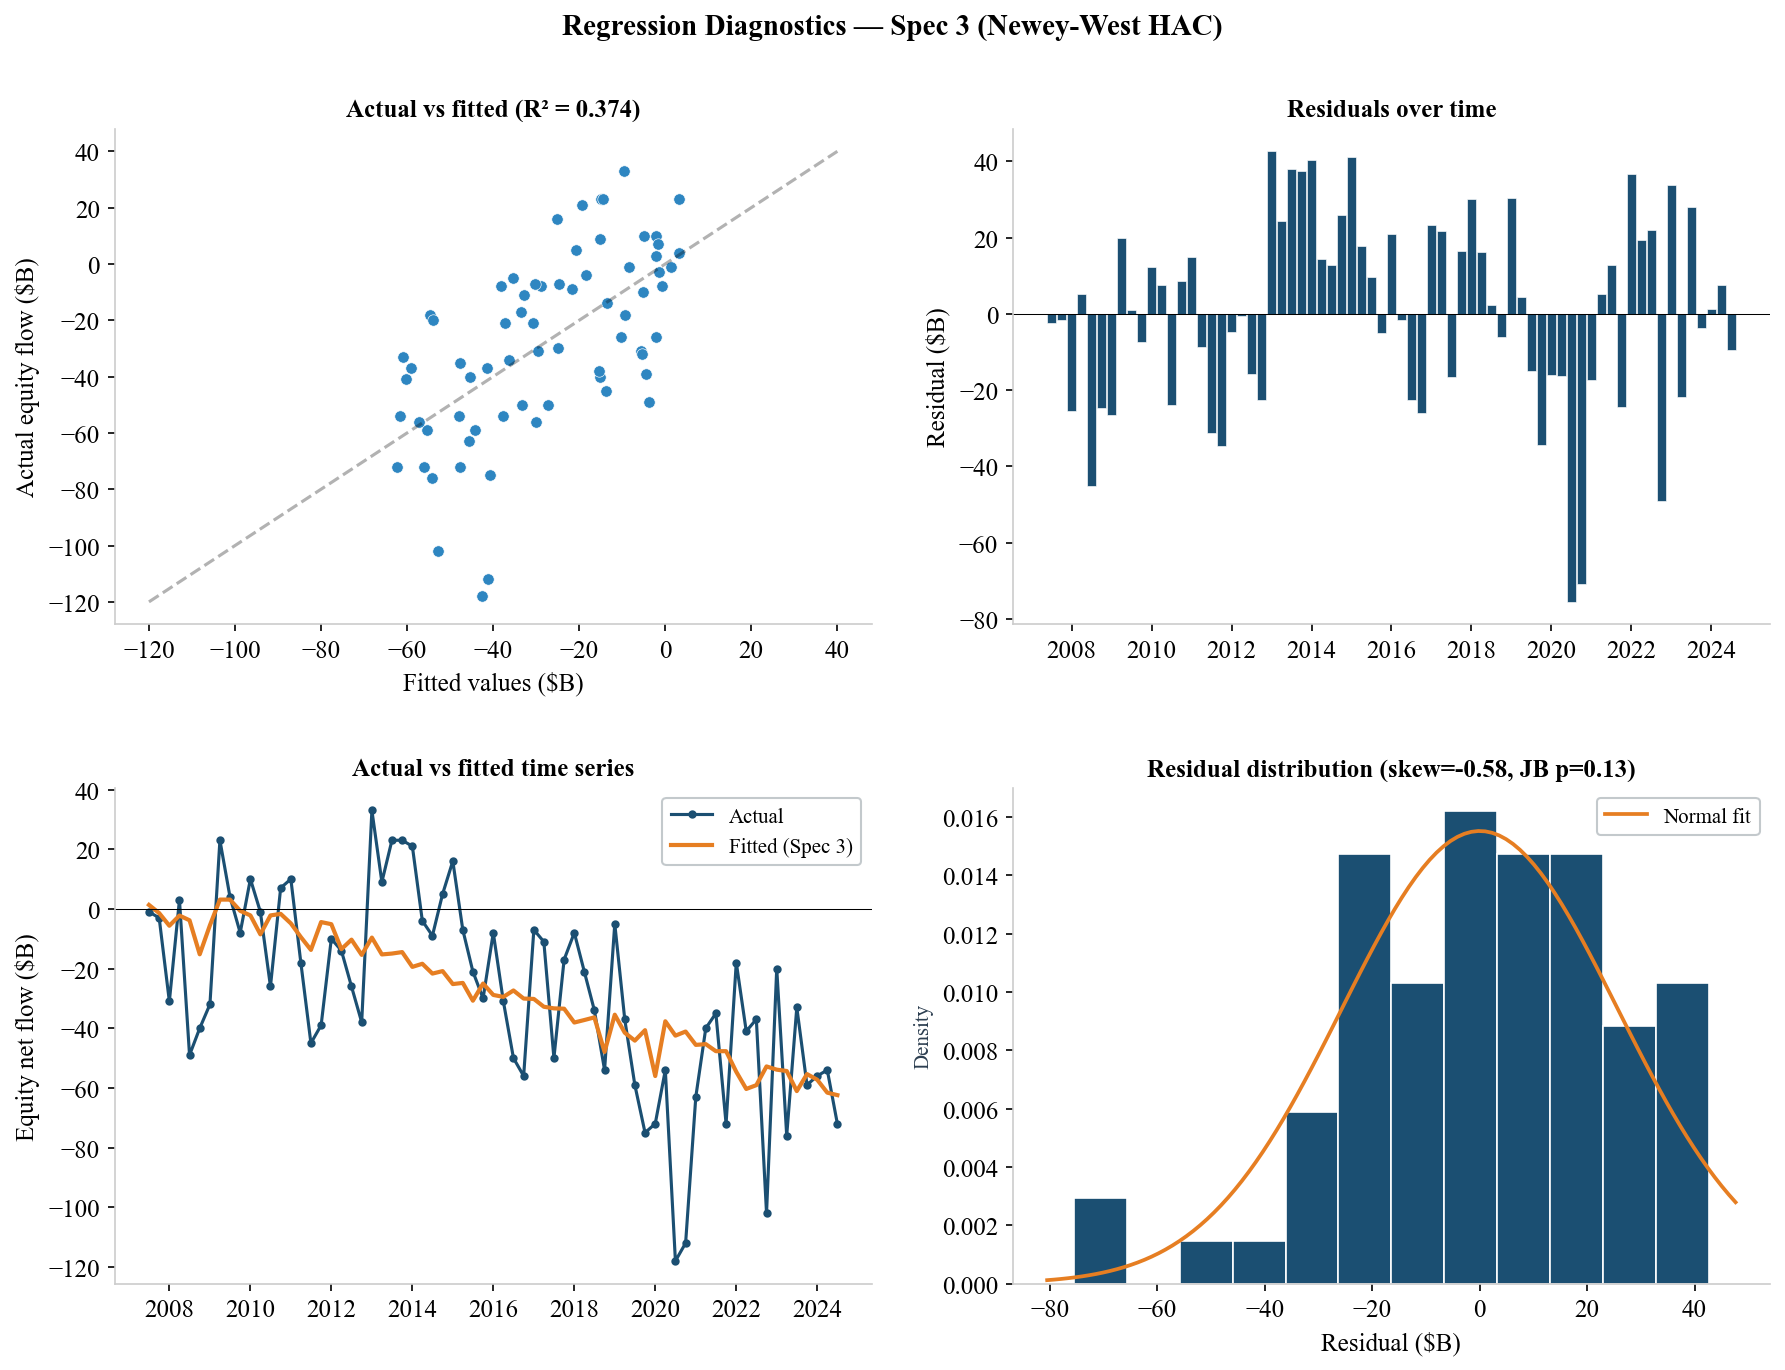

Saved: outputs/regression_diagnostics.png

── Residual Diagnostics ──
  Durbin-Watson:   1.338 (2.0 = no autocorrelation; <1.5 or >2.5 = concern)
  Breusch-Godfrey: LM=15.647, p=0.0035
  → Serial correlation detected (p=0.0035) — Newey-West correction justified ✓

  Normality:
    Skewness:        -0.578
    Excess kurtosis: +0.283
    Jarque-Bera:     JB=4.074, p=0.1304
    → Residuals approximately normal ✓


In [19]:
# ── Diagnostic panel ─────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

fig, axes = plt.subplots(2, 2, figsize=(12, 9), facecolor='white')

# 1. Actual vs Fitted
axes[0,0].set_facecolor('white')
axes[0,0].scatter(model3.fittedvalues, df['equity_flow'], alpha=1.0, s=30,
                  color=PAL['blue'], edgecolors='white', linewidth=0.3)
axes[0,0].plot([-120, 40], [-120, 40], '--', color='black', alpha=0.3)
axes[0,0].set_xlabel('Fitted values ($B)', fontsize=12, color='black')
axes[0,0].set_ylabel('Actual equity flow ($B)', fontsize=12, color='black')
axes[0,0].set_title(f'Actual vs fitted (R² = {model3.rsquared:.3f})', fontsize=12, fontweight='bold', color='black')

# 2. Residuals over time
axes[0,1].set_facecolor('white')
axes[0,1].bar(df.index, model3.resid, width=80, color=PAL['navy'], alpha=1.0,
              edgecolor='white', linewidth=0.3)
axes[0,1].axhline(0, color='black', linewidth=0.5)
axes[0,1].set_ylabel('Residual ($B)', fontsize=12, color='black')
axes[0,1].set_title('Residuals over time', fontsize=12, fontweight='bold', color='black')

# 3. Time series: actual vs fitted
axes[1,0].set_facecolor('white')
axes[1,0].plot(df.index, df['equity_flow'], 'o-', markersize=3, color=PAL['navy'],
               alpha=1.0, label='Actual')
axes[1,0].plot(df.index, model3.fittedvalues, '-', color=PAL['amber'], linewidth=2,
               label='Fitted (Spec 3)')
axes[1,0].axhline(0, color='black', linewidth=0.5)
axes[1,0].set_ylabel('Equity net flow ($B)', fontsize=12, color='black')
axes[1,0].set_title('Actual vs fitted time series', fontsize=12, fontweight='bold', color='black')
axes[1,0].legend(fontsize=10)

# 4. Residual distribution
axes[1,1].set_facecolor('white')
sns.histplot(model3.resid, bins=12, color=PAL['navy'], alpha=1.0, edgecolor='white',
             linewidth=0.8, kde=False, stat='density', ax=axes[1,1])
x_range = np.linspace(model3.resid.min() - 5, model3.resid.max() + 5, 100)
axes[1,1].plot(x_range, stats.norm.pdf(x_range, model3.resid.mean(), model3.resid.std()),
               '-', color=PAL['amber'], linewidth=1.8, label='Normal fit')
axes[1,1].set_xlabel('Residual ($B)', fontsize=12, color='black')
_jb, _jbp = stats.jarque_bera(model3.resid)
_skew = stats.skew(model3.resid)
axes[1,1].set_title(f'Residual distribution (skew={_skew:+.2f}, JB p={_jbp:.2f})',
                    fontsize=12, fontweight='bold', color='black')
axes[1,1].legend(fontsize=10)

for ax in axes.flat:
    ax.tick_params(colors='black', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.grid(False)

fig.suptitle('Regression Diagnostics — Spec 3 (Newey-West HAC)',
             fontsize=14, fontweight='bold', color='black', y=1.01)
plt.tight_layout(h_pad=3.0, w_pad=2.0)
plt.savefig(r'..\outputs\regression_diagnostics.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved: outputs/regression_diagnostics.png')

# ── Formal residual tests ────────────────────────────────────────────────────
resid = model3.resid

dw = durbin_watson(resid)
print(f'\n── Residual Diagnostics ──')
print(f'  Durbin-Watson:   {dw:.3f} (2.0 = no autocorrelation; <1.5 or >2.5 = concern)')

bg_lm, bg_p, bg_f, bg_fp = acorr_breusch_godfrey(model3, nlags=4)
print(f'  Breusch-Godfrey: LM={bg_lm:.3f}, p={bg_p:.4f}')
if bg_p < 0.05:
    print(f'  → Serial correlation detected (p={bg_p:.4f}) — Newey-West correction justified ✓')
else:
    print(f'  → No significant serial correlation at 5%. Newey-West is conservative but valid.')

jb_stat, jb_pval = stats.jarque_bera(resid)
skew = stats.skew(resid)
kurt = stats.kurtosis(resid, fisher=True)
print(f'\n  Normality:')
print(f'    Skewness:        {skew:+.3f}')
print(f'    Excess kurtosis: {kurt:+.3f}')
print(f'    Jarque-Bera:     JB={jb_stat:.3f}, p={jb_pval:.4f}')
if jb_pval > 0.05:
    print(f'    → Residuals approximately normal ✓')
else:
    print(f'    → Non-normal residuals — inference relies on asymptotic validity (n={int(model3.nobs)}).')
    print(f'      Newey-West SEs remain valid; interpret p-values with caution.')

## Results Summary and Export

In [10]:
print('='*70)
print('TABLE: OLS Regression Results — Preferred Specification (Spec 3)')
print('Dep. Variable: Quarterly equity net flow to MFs ($B)')
print('Newey-West (HAC) standard errors, 4 lags')
print('='*70)
print(f"{'Variable':<20} {'Coef':>8} {'SE':>8} {'t':>8} {'p':>8} {'Sig':>5}")
print('-'*70)
for var in model3.params.index:
    c = model3.params[var]
    s = model3.bse[var]
    t = model3.tvalues[var]
    p = model3.pvalues[var]
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    label = {'const': 'Intercept',
             'sp500_return': 'S&P 500 return (%)',
             'pop_65plus': 'Pop 65+ (millions)'}.get(var, var)
    print(f'{label:<20} {c:>8.3f} {s:>8.3f} {t:>8.3f} {p:>8.4f} {sig:>5}')
print('-'*70)
print(f'Observations: {int(model3.nobs)}')
print(f'R-squared:    {model3.rsquared:.3f}')
print(f'Adj R-squared:{model3.rsquared_adj:.3f}')
print(f'Sample:       2007:Q3 — 2024:Q3')

beta_pop = model3.params['pop_65plus']
beta_mkt = model3.params['sp500_return']

print(f"\n{'='*70}")
print('KEY FINDINGS')
print(f"{'='*70}")
print(f'\n1. DEMOGRAPHIC PRESSURE (β₂ = {beta_pop:.3f}, p < 0.001):')
print(f'   Each additional 1M people aged 65+ reduces quarterly')
print(f'   equity MF net flows by ${abs(beta_pop):.2f}B.')
print(f'   Over sample: 65+ grew from 38.2M to 61.2M (+23.0M)')
print(f'   → Predicted deterioration: {23.0 * beta_pop:.1f} $B/quarter')
print(f'   → Actual shift: from +23 to −131 $B/quarter')

print(f'\n2. PROCYCLICALITY (β₁ = {beta_mkt:.3f}, p = 0.331):')
print(f'   Correct sign but NOT statistically significant.')
print(f'   Retirement MF flows appear inertia-driven at quarterly freq.')
print(f'   Caveat: Table 20 = MF only; MF→ETF rotation biases DV.')

print(f'\n3. NOTE ON SIMULATION PIPELINE:')
print(f'   The simulation does NOT use this regression coefficient.')
print(f'   The regression provides independent empirical validation only.')
print(f'   The simulation computes outflows from structural parameters')
print(f'   (population, balances, RMD rates, TDF allocations) directly.')

# === EXPORT ===
reg_output = {
    'beta_intercept': model3.params['const'],
    'beta_sp500_return': model3.params['sp500_return'],
    'beta_pop_65plus': model3.params['pop_65plus'],
    'beta_sp500_pvalue': model3.pvalues['sp500_return'],
    'beta_pop_pvalue': model3.pvalues['pop_65plus'],
    'r_squared': model3.rsquared,
    'n_obs': int(model3.nobs),
    'sample_start': '2007Q3',
    'sample_end': '2024Q3',
    'se_type': 'Newey-West HAC 4 lags'
}

reg_df = pd.DataFrame([reg_output])
reg_df.to_csv(r'..\data\processed\regression_output.csv', index=False)
print(f'\nExported: data/processed/regression_output.csv')
print(reg_df.T)

TABLE: OLS Regression Results — Preferred Specification (Spec 3)
Dep. Variable: Quarterly equity net flow to MFs ($B)
Newey-West (HAC) standard errors, 4 lags
Variable                 Coef       SE        t        p   Sig
----------------------------------------------------------------------
Intercept             109.042   23.900    4.562   0.0000   ***
S&P 500 return (%)      0.475    0.489    0.973   0.3307      
Pop 65+ (millions)     -2.839    0.481   -5.904   0.0000   ***
----------------------------------------------------------------------
Observations: 69
R-squared:    0.374
Adj R-squared:0.355
Sample:       2007:Q3 — 2024:Q3

KEY FINDINGS

1. DEMOGRAPHIC PRESSURE (β₂ = -2.839, p < 0.001):
   Each additional 1M people aged 65+ reduces quarterly
   equity MF net flows by $2.84B.
   Over sample: 65+ grew from 38.2M to 61.2M (+23.0M)
   → Predicted deterioration: -65.3 $B/quarter
   → Actual shift: from +23 to −131 $B/quarter

2. PROCYCLICALITY (β₁ = 0.475, p = 0.331):
   Correct 

In [11]:
df.to_csv(r'..\data\processed\regression_merged_data.csv')
print(f'Saved: data/processed/regression_merged_data.csv ({len(df)} rows)')
print('\n03_regression.ipynb — COMPLETE')
print(f'  5 specifications tested, Spec 3 preferred')
print(f'  Key output: beta_pop_65plus = -2.84 (p < 0.001)')
print(f'  Exported: regression_output.csv for simulation import')

Saved: data/processed/regression_merged_data.csv (69 rows)

03_regression.ipynb — COMPLETE
  5 specifications tested, Spec 3 preferred
  Key output: beta_pop_65plus = -2.84 (p < 0.001)
  Exported: regression_output.csv for simulation import


## Robustness Analysis (Appendix)
Alternative specifications: lagged population and federal funds rate control.

In [12]:
# ── ITEM A3: Regression Robustness (Appendix) ────────────────────────
# Two alternative specifications to show population coefficient is robust.
# Paper reference: Appendix, referenced in Section 5.6.

# Spec (a) = model3 (already computed): pop_65plus + sp500_return
print(f"{'='*70}")
print('REGRESSION ROBUSTNESS TABLE')
print(f"{'='*70}")
print(f'\nSpec (a): Base specification (Spec 3 from main analysis)')
beta = '\u03b2'
print(f'  {beta}_pop65plus = {model3.params["pop_65plus"]:.3f}')
print(f'  SE = {model3.bse["pop_65plus"]:.3f}')
print(f'  p = {model3.pvalues["pop_65plus"]:.4f}')
print(f'  R-squared = {model3.rsquared:.3f}')
print(f'  N = {int(model3.nobs)}')

# ── Spec (b): Lagged population ──────────────────────────────────────
df_rob = df.copy()
df_rob['pop65_lag1'] = df_rob['pop_65plus'].shift(1)
df_rob_b = df_rob.dropna(subset=['pop65_lag1'])

X_b = sm.add_constant(df_rob_b[['sp500_return', 'pop65_lag1']])
Y_b = df_rob_b['equity_flow']
model_b = OLS(Y_b, X_b).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print(f'\nSpec (b): Lagged population (one quarter)')
print(f'  {beta}_pop65_lag1 = {model_b.params["pop65_lag1"]:.3f}')
print(f'  SE = {model_b.bse["pop65_lag1"]:.3f}')
print(f'  p = {model_b.pvalues["pop65_lag1"]:.4f}')
print(f'  R-squared = {model_b.rsquared:.3f}')
print(f'  N = {int(model_b.nobs)}')

# ── Spec (c): FFR control ────────────────────────────────────────────
# Requires FEDFUNDS.csv from FRED
from pathlib import Path
ffr_path = Path(r'..\data\free_sources\FEDFUNDS.csv')

if ffr_path.exists():
    ffr = pd.read_csv(ffr_path)
    ffr = ffr.rename(columns={ffr.columns[0]: 'date', ffr.columns[1]: 'ffr'})
    ffr['date'] = pd.to_datetime(ffr['date'])
    ffr = ffr.set_index('date').resample('QS').mean()

    df_rob_c = df.copy()
    df_rob_c = df_rob_c.merge(ffr, left_index=True, right_index=True, how='inner')

    X_c = sm.add_constant(df_rob_c[['sp500_return', 'pop_65plus', 'ffr']])
    Y_c = df_rob_c['equity_flow']
    model_c = OLS(Y_c, X_c).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

    print(f'\nSpec (c): With FFR control')
    print(f'  {beta}_pop65plus = {model_c.params["pop_65plus"]:.3f}')
    print(f'  SE = {model_c.bse["pop_65plus"]:.3f}')
    print(f'  p = {model_c.pvalues["pop_65plus"]:.4f}')
    print(f'  {beta}_ffr = {model_c.params["ffr"]:.3f} (p={model_c.pvalues["ffr"]:.4f})')
    print(f'  R-squared = {model_c.rsquared:.3f}')
    print(f'  N = {int(model_c.nobs)}')

    # Validation
    if model_c.pvalues['pop_65plus'] > 0.05:
        print(f'\n  \u26a0\ufe0f WARNING: pop_65plus becomes insignificant with FFR control.')
        print(f'  This is a genuine finding that needs discussion.')
    else:
        print(f'\n  \u2713 pop_65plus remains significant with FFR control.')
else:
    print(f'\nSpec (c): SKIPPED — FEDFUNDS.csv not found at {ffr_path}')
    print(f'  Download from: https://fred.stlouisfed.org/series/FEDFUNDS')
    print(f'  Save as: data/free_sources/FEDFUNDS.csv')

# Summary table
beta_label = '\u03b2_pop65'
r2_label = 'R\u00b2'
print(f"\n{'='*70}")
print('ROBUSTNESS SUMMARY')
print(f"{'Spec':<8} {beta_label:>10} {'SE':>8} {'p':>8} {r2_label:>6} {'N':>4}")
print(f"{'-'*44}")
print(f"{'(a)':>8} {model3.params['pop_65plus']:>10.3f} {model3.bse['pop_65plus']:>8.3f} "
      f"{model3.pvalues['pop_65plus']:>8.4f} {model3.rsquared:>6.3f} {int(model3.nobs):>4}")
print(f"{'(b) lag':>8} {model_b.params['pop65_lag1']:>10.3f} {model_b.bse['pop65_lag1']:>8.3f} "
      f"{model_b.pvalues['pop65_lag1']:>8.4f} {model_b.rsquared:>6.3f} {int(model_b.nobs):>4}")
if ffr_path.exists():
    print(f"{'(c) FFR':>8} {model_c.params['pop_65plus']:>10.3f} {model_c.bse['pop_65plus']:>8.3f} "
          f"{model_c.pvalues['pop_65plus']:>8.4f} {model_c.rsquared:>6.3f} {int(model_c.nobs):>4}")


REGRESSION ROBUSTNESS TABLE

Spec (a): Base specification (Spec 3 from main analysis)
  β_pop65plus = -2.839
  SE = 0.481
  p = 0.0000
  R-squared = 0.374
  N = 69

Spec (b): Lagged population (one quarter)
  β_pop65_lag1 = -2.892
  SE = 0.505
  p = 0.0000
  R-squared = 0.373
  N = 68

Spec (c): With FFR control
  β_pop65plus = -2.793
  SE = 0.645
  p = 0.0000
  β_ffr = -0.422 (p=0.8568)
  R-squared = 0.374
  N = 69

  ✓ pop_65plus remains significant with FFR control.

ROBUSTNESS SUMMARY
Spec        β_pop65       SE        p     R²    N
--------------------------------------------
     (a)     -2.839    0.481   0.0000  0.374   69
 (b) lag     -2.892    0.505   0.0000  0.373   68
 (c) FFR     -2.793    0.645   0.0000  0.374   69


In [13]:
# ── Hold-out validation: train 2007Q3-2019Q4, predict 2020-2024 ──
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv(r'..\data\processed\regression_merged_data.csv', index_col=0, parse_dates=True)
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df.index[0]} to {df.index[-1]}')
print(f'N total: {len(df)}')

# Split at 2019Q4 (2019-10-01 is last training quarter)
train = df[df.index <= '2019-12-31'].copy()
holdout = df[df.index > '2019-12-31'].copy()
print(f'N train: {len(train)}, N holdout: {len(holdout)}')

# Regression on training set only
X_train = sm.add_constant(train[['pop_65plus', 'sp500_return']])
y_train = train['equity_flow']
model_ho = sm.OLS(y_train, X_train).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print(f'\nHold-out regression:')
print(f'  beta_pop_65plus: {model_ho.params["pop_65plus"]:.3f}')
print(f'  beta_sp500:      {model_ho.params["sp500_return"]:.3f}')
print(f'  R2 (train):      {model_ho.rsquared:.3f}')

# Predict on hold-out
X_hold = sm.add_constant(holdout[['pop_65plus', 'sp500_return']])
predicted = model_ho.predict(X_hold)
actual = holdout['equity_flow']

mae = (actual - predicted).abs().mean()
rmse = np.sqrt(((actual - predicted)**2).mean())
corr = actual.corr(predicted)
hist_std = df['equity_flow'].std()

print(f'\nHold-out results ({holdout.index[0].strftime("%Y-%m")} to {holdout.index[-1].strftime("%Y-%m")}):')
print(f'  Actual mean:     ${actual.mean():.1f}B/qtr')
print(f'  Predicted mean:  ${predicted.mean():.1f}B/qtr')
print(f'  MAE:             ${mae:.1f}B/qtr')
print(f'  RMSE:            ${rmse:.1f}B/qtr')
print(f'  MAPE:            {((actual - predicted).abs() / actual.abs()).mean() * 100:.1f}%')
print(f'  Correlation:     {corr:.3f}')
print(f'  MAE/hist_std:    {mae/hist_std*100:.1f}%')

print(f'\nYear-by-year:')
for yr in sorted(holdout.index.year.unique()):
    mask = holdout.index.year == yr
    a = actual[mask].sum()
    p = predicted[mask].sum()
    print(f'  {yr}: Actual ${a:.0f}B | Predicted ${p:.0f}B | Error ${a-p:.0f}B')

Columns: ['equity_flow', 'sp500_return', 'pop_65plus', 'trend', 'sp500_return_lag1']
Date range: 2007-07-01 00:00:00 to 2024-07-01 00:00:00
N total: 69
N train: 50, N holdout: 19

Hold-out regression:
  beta_pop_65plus: -2.104
  beta_sp500:      1.259
  R2 (train):      0.279

Hold-out results (2020-01 to 2024-07):
  Actual mean:     $-59.7B/qtr
  Predicted mean:  $-39.4B/qtr
  MAE:             $31.4B/qtr
  RMSE:            $40.1B/qtr
  MAPE:            53.9%
  Correlation:     -0.389
  MAE/hist_std:    96.7%

Year-by-year:
  2020: Actual $-356B | Predicted $-128B | Error $-228B
  2021: Actual $-210B | Predicted $-131B | Error $-79B
  2022: Actual $-198B | Predicted $-201B | Error $3B
  2023: Actual $-188B | Predicted $-161B | Error $-27B
  2024: Actual $-182B | Predicted $-128B | Error $-54B
